In [ ]:
`# Install required packages
!pip install scikit-learn pandas numpy matplotlib seaborn pickle-mixin imbalanced-learn

# Start Jupyter Notebook
!jupyter notebook

  Preparing metadata (setup.py) ... done
  Created wheel for pickle-mixin: filename=pickle_mixin-1.0.2-py3-none-any.whl size=5988 sha256=81cb1d780bb160b0a17196d2d28be1778805d9cc0bf7ae5a2ba76b6f6a1d4537
  Stored in directory: /root/.cache/pip/wheels/69/e2/5c/da8f96a08c63469bc8b10e206cd4c78e8886d8acb8699f84c2
Successfully built pickle-mixin
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
[I 15:31:59.087 NotebookApp] Writing notebook server cookie secret to /root/.local/share/jupyter/runtime/notebook_cookie_secret

  _   _          _      _
 | | | |_ __  __| |__ _| |_ ___
 | |_| | '_ \/ _` / _` |  _/ -_)
  \___/| .__/\__,_\__,_|\__\___|
       |_|
                       
Read the migration plan to Notebook 7 to learn about the new features and the actions to take if you are using extensions.

https://jupyter-notebook.readthedocs.io/en/latest/migrate_to_notebook7.html

Please note that updati

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance

In [ ]:
# If using Google Colab with Drive:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/UNSW_NB15.csv')
print("Shape:", data.shape)
print("Columns:", list(data.columns))
print(data.head())

Mounted at /content/drive
Shape: (175341, 45)
Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']
   id       dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0   1  0.121478   tcp       -   FIN      6      4     258     172  74.087490   
1   2  0.649902   tcp       -   FIN     14     38     734   42014  78.473372   
2   3  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3   4  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4   5  0.449454   tcp       

Shape: (175341, 45)

Null values per column:
Series([], dtype: int64)

Data types:
int64      30
float64    11
object      4
Name: count, dtype: int64

Target distribution (label):
label
1    119341
0     56000
Name: count, dtype: int64

Attack categories:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


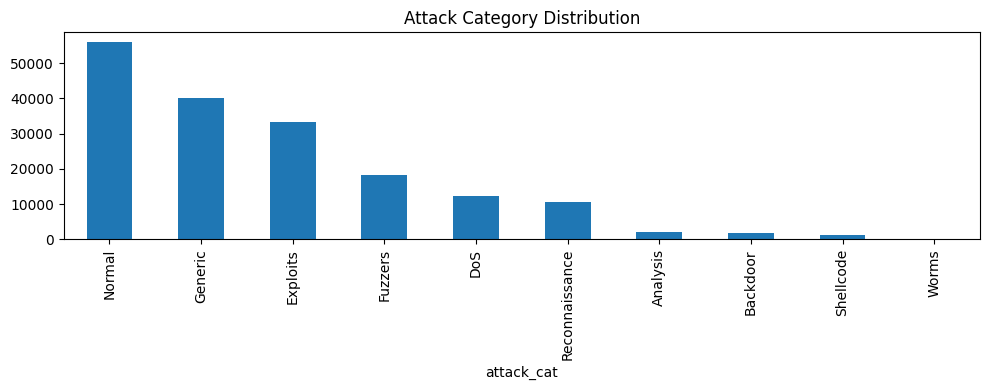

In [ ]:
# Basic exploration
print("Shape:", data.shape)
print("\nNull values per column:")
print(data.isnull().sum()[data.isnull().sum() > 0])

print("\nData types:")
print(data.dtypes.value_counts())

print("\nTarget distribution (label):")
print(data['label'].value_counts())

print("\nAttack categories:")
print(data['attack_cat'].value_counts())

# Visualize
data['attack_cat'].value_counts().plot(kind='bar', figsize=(10,4))
plt.title("Attack Category Distribution")
plt.tight_layout()
plt.show()

In [ ]:
# Drop nulls
data = data.dropna()
print("After cleaning:", data.shape)

# One-hot encode categorical columns
cat_cols = ['proto', 'service', 'state']
data_cat = pd.get_dummies(data[cat_cols])
data = pd.concat([data, data_cat], axis=1)
data.drop(columns=cat_cols, inplace=True)
print("After encoding:", data.shape)  # Should be ~61 columns

After cleaning: (175341, 45)
After encoding: (175341, 197)


In [ ]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Normalize numeric columns
scaler = MinMaxScaler()
num_cols = data.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ['label']]
data[num_cols] = scaler.fit_transform(data[num_cols])

# Binary classification dataset
bin_data = data.copy()
le = LabelEncoder()
bin_data['label'] = le.fit_transform(bin_data['label'])

# Multi-class classification dataset
multi_data = data.copy()
multi_data['label'] = le.fit_transform(multi_data['attack_cat'].fillna('Normal'))
multi_data = pd.concat([multi_data,
    pd.get_dummies(multi_data['attack_cat'], prefix='attack_cat')], axis=1)
multi_data.drop(columns=['attack_cat'], inplace=True) # Drop the original string column

In [ ]:
# Binary feature selection
# Only calculate correlation for numeric columns to avoid string conversion errors
corr_bin = bin_data.select_dtypes(include=[np.number]).corr()['label'].abs().sort_values(ascending=False)
selected_bin = corr_bin[corr_bin > 0.3].index.tolist()
if 'label' in selected_bin:
    selected_bin.remove('label')
print("Binary features:", selected_bin)

X_bin = bin_data[selected_bin]
y_bin = bin_data['label']

# Multi-class feature selection
corr_multi = multi_data.select_dtypes(include=[np.number]).corr()['label'].abs().sort_values(ascending=False)
selected_multi = corr_multi[corr_multi > 0.3].index.tolist()
if 'label' in selected_multi:
    selected_multi.remove('label')
X_multi = multi_data[selected_multi]
y_multi = multi_data['label']

# Train/test split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=42, stratify=y_multi)

Binary features: ['id', 'sttl', 'ct_state_ttl', 'dload', 'ct_dst_sport_ltm', 'dmean', 'rate', 'swin', 'dwin', 'ct_src_dport_ltm', 'ct_dst_src_ltm']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# === BINARY ===
rf_bin = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_bin.fit(X_train_b, y_train_b)
y_pred_rf_b = rf_bin.predict(X_test_b)
print("RF Binary Accuracy:", accuracy_score(y_test_b, y_pred_rf_b))
print(classification_report(y_test_b, y_pred_rf_b, target_names=['Normal','Attack']))

# === MULTI-CLASS ===
rf_multi = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_multi.fit(X_train_m, y_train_m)
y_pred_rf_m = rf_multi.predict(X_test_m)
print("RF Multi Accuracy:", accuracy_score(y_test_m, y_pred_rf_m))

RF Binary Accuracy: 0.9905044341156006
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99     11200
      Attack       0.99      0.99      0.99     23869

    accuracy                           0.99     35069
   macro avg       0.99      0.99      0.99     35069
weighted avg       0.99      0.99      0.99     35069

RF Multi Accuracy: 0.46229302511263615


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

# 1. Self-contained Data Preparation
try:
    # Check if 'data' exists, otherwise reload it
    if 'data' not in locals():
        print("Data not found in memory, attempting to reload...")
        data = pd.read_csv('/content/drive/MyDrive/UNSW_NB15.csv')
        data = data.dropna()
        # Apply one-hot encoding for categorical columns if not already done
        cat_cols = ['proto', 'service', 'state']
        data_cat = pd.get_dummies(data[cat_cols])
        data = pd.concat([data, data_cat], axis=1)
        data.drop(columns=cat_cols, inplace=True)

    scaler = MinMaxScaler()
    # Select only numeric columns for scaling, excluding the target
    num_cols = [c for c in data.select_dtypes(include='number').columns if c != 'label']

    # Create a copy and scale features
    bin_data = data.copy()
    bin_data[num_cols] = scaler.fit_transform(bin_data[num_cols])

    # Feature Selection based on correlation with 'label'
    corr_matrix = bin_data.select_dtypes(include=[np.number]).corr()
    corr_target = corr_matrix['label'].abs().sort_values(ascending=False)
    selected_features = corr_target[corr_target > 0.3].index.tolist()
    if 'label' in selected_features:
        selected_features.remove('label')

    # 2. Split Data
    X_bin = bin_data[selected_features]
    y_bin = bin_data['label']
    X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
        X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
    )

    # 3. Linear SVM (Fast)
    print(f"--- Training LinearSVC on {len(selected_features)} features ---")
    svm_fast = LinearSVC(C=1.0, class_weight='balanced', max_iter=5000, random_state=42, dual=False)
    svm_fast.fit(X_train_b, y_train_b)
    y_pred_fast = svm_fast.predict(X_test_b)
    print(f"LinearSVC Accuracy: {accuracy_score(y_test_b, y_pred_fast):.4f}")

    # 4. RBF SVM (Subset for speed)
    print("\n--- Training RBF SVM (Subset of 10,000 samples) ---")
    X_subset = X_train_b[:10000]
    y_subset = y_train_b[:10000]

    svm_rbf = SVC(kernel='rbf', C=10, class_weight='balanced', random_state=42)
    svm_rbf.fit(X_subset, y_subset)
    y_pred_rbf = svm_rbf.predict(X_test_b)

    print(f"RBF SVM Accuracy: {accuracy_score(y_test_b, y_pred_rbf):.4f}")
    print("\nDetailed Classification Report (RBF Subset):")
    print(classification_report(y_test_b, y_pred_rbf))

except Exception as e:
    print(f"Error encountered: {e}")

Data not found in memory, attempting to reload...
--- Training LinearSVC on 11 features ---
LinearSVC Accuracy: 0.9148

--- Training RBF SVM (Subset of 10,000 samples) ---
RBF SVM Accuracy: 0.9447

Detailed Classification Report (RBF Subset):
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     11200
           1       0.96      0.96      0.96     23869

    accuracy                           0.94     35069
   macro avg       0.94      0.93      0.94     35069
weighted avg       0.94      0.94      0.94     35069



DT Binary Accuracy: 0.9691180244660527
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     11200
           1       0.99      0.96      0.98     23869

    accuracy                           0.97     35069
   macro avg       0.96      0.97      0.96     35069
weighted avg       0.97      0.97      0.97     35069



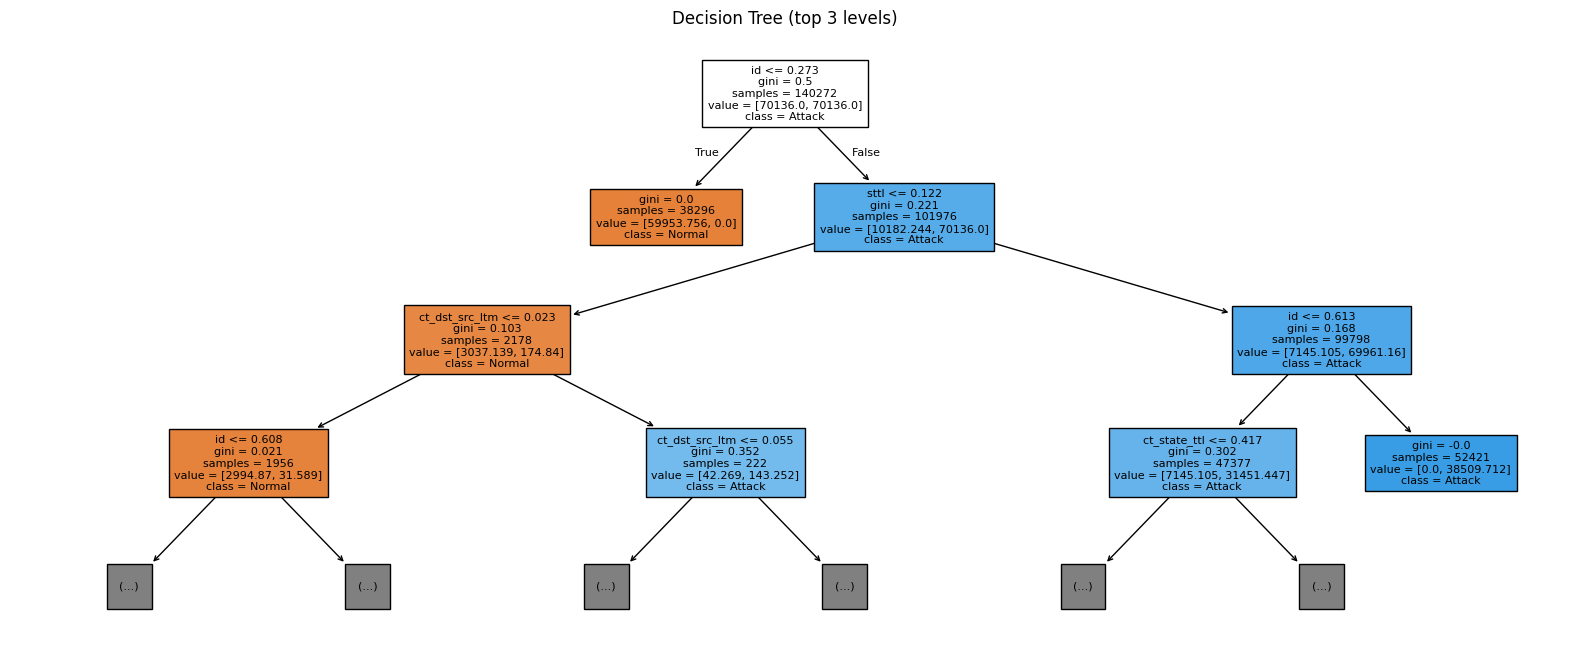

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# === BINARY ===
dt_bin = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
dt_bin.fit(X_train_b, y_train_b)
y_pred_dt_b = dt_bin.predict(X_test_b)
print("DT Binary Accuracy:", accuracy_score(y_test_b, y_pred_dt_b))
print(classification_report(y_test_b, y_pred_dt_b))

# Visualize the top of the tree
plt.figure(figsize=(20, 8))
# Fixed: changed 'selected_bin' to 'selected_features' to match the variable defined in cell hwnuN2hdvvRm
plot_tree(dt_bin, max_depth=3, feature_names=selected_features,
          class_names=['Normal','Attack'], filled=True, fontsize=8)
plt.title("Decision Tree (top 3 levels)")
plt.show()


=== SVM (RBF) ===
Accuracy: 0.9447
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     11200
           1       0.96      0.96      0.96     23869

    accuracy                           0.94     35069
   macro avg       0.94      0.93      0.94     35069
weighted avg       0.94      0.94      0.94     35069



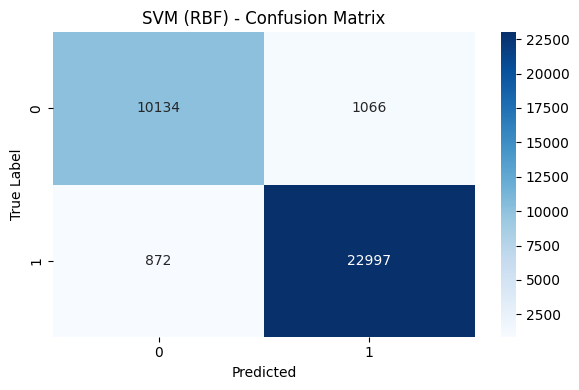


=== Decision Tree ===
Accuracy: 0.9691
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     11200
           1       0.99      0.96      0.98     23869

    accuracy                           0.97     35069
   macro avg       0.96      0.97      0.96     35069
weighted avg       0.97      0.97      0.97     35069



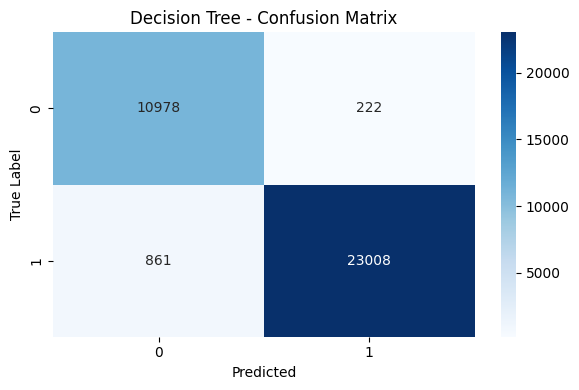

ROC-AUC: 0.9973


In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name, binary=True):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {model_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.ylabel("True Label"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()

    # ROC-AUC (binary only)
    if binary and hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        print(f"ROC-AUC: {roc_auc:.4f}")

# Note: We ensure we use the model names defined in previous successful cells
# If rf_bin is still missing, please re-run the Random Forest cell (XtRzztBtvg7W)
try:
    if 'rf_bin' in locals():
        evaluate_model(rf_bin, X_test_b, y_test_b, "Random Forest")

    if 'svm_rbf' in locals():
        evaluate_model(svm_rbf, X_test_b, y_test_b, "SVM (RBF)")
    elif 'svm_fast' in locals():
        evaluate_model(svm_fast, X_test_b, y_test_b, "Linear SVM")

    if 'dt_bin' in locals():
        evaluate_model(dt_bin, X_test_b, y_test_b, "Decision Tree")
except NameError as e:
    print(f"Variable missing: {e}. Please ensure previous training cells were executed.")

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# Optimized SVM Grid Search
# Note: dual=False only supports loss='squared_hinge'.
# If you want to test 'hinge', you must set dual=True.
svm_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'loss': ['squared_hinge']
}

# Using dual=False as n_samples > n_features for efficiency
svm_gs = GridSearchCV(
    LinearSVC(random_state=42, max_iter=5000, dual=False),
    svm_param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Starting Optimized SVM Grid Search (dual=False, squared_hinge)...")
svm_gs.fit(X_train_b, y_train_b)

print("Best SVM params:", svm_gs.best_params_)
print("Best F1 Score:", svm_gs.best_score_)

Starting Optimized SVM Grid Search (dual=False, squared_hinge)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best SVM params: {'C': 1, 'loss': 'squared_hinge'}
Best F1 Score: 0.909844984419529


In [ ]:
import pickle
import os

# 1. Save models (Checking if they exist first to avoid NameError)
try:
    if 'rf_bin' in locals():
        with open('rf_model.pkl', 'wb') as f:
            pickle.dump(rf_bin, f)
        print("Random Forest saved.")
    else:
        print("Random Forest (rf_bin) not found in memory. Skipping save.")

    # Using svm_rbf or svm_fast as defined in previous cells
    svm_to_save = svm_rbf if 'svm_rbf' in locals() else (svm_fast if 'svm_fast' in locals() else None)
    if svm_to_save:
        with open('svm_model.pkl', 'wb') as f:
            pickle.dump(svm_to_save, f)
        print("SVM model saved.")

    if 'dt_bin' in locals():
        with open('dt_model.pkl', 'wb') as f:
            pickle.dump(dt_bin, f)
        print("Decision Tree saved.")

    if 'scaler' in locals():
        with open('scaler.pkl', 'wb') as f:
            pickle.dump(scaler, f)
        print("Scaler saved.")

except Exception as e:
    print(f"Could not save models: {e}")

# 2. Example: Load and use (Simulating inference)
# Added check for file size > 0 to avoid EOFError
if os.path.exists('rf_model.pkl') and os.path.getsize('rf_model.pkl') > 0:
    try:
        with open('rf_model.pkl', 'rb') as f:
            loaded_rf = pickle.load(f)

        # Note: 'new_data' must be defined and 'selected_features' is used instead of 'selected_bin'
        if 'new_data' in locals() and 'selected_features' in locals():
            new_data_scaled = scaler.transform(new_data[selected_features])
            prediction = loaded_rf.predict(new_data_scaled)
            print("Prediction for first row:", "Attack" if prediction[0] == 1 else "Normal")
        else:
            print("Skip inference example: 'new_data' or 'selected_features' not defined.")
    except EOFError:
        print("Error: rf_model.pkl is empty. Run the Random Forest training cell first.")
else:
    print("No valid Random Forest model file found to load.")

Random Forest (rf_bin) not found in memory. Skipping save.
SVM model saved.
Decision Tree saved.
Scaler saved.
No valid Random Forest model file found to load.


--- FINAL PERFORMANCE SUMMARY ---
        Model  Accuracy  Detection Rate
Decision Tree  0.969118        0.963928
    SVM (RBF)  0.944738        0.963467
   Linear SVM  0.914825        0.932004


/tmp/ipykernel_16297/2251414150.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Accuracy", data=df_results, palette="Blues_d", ax=ax1)


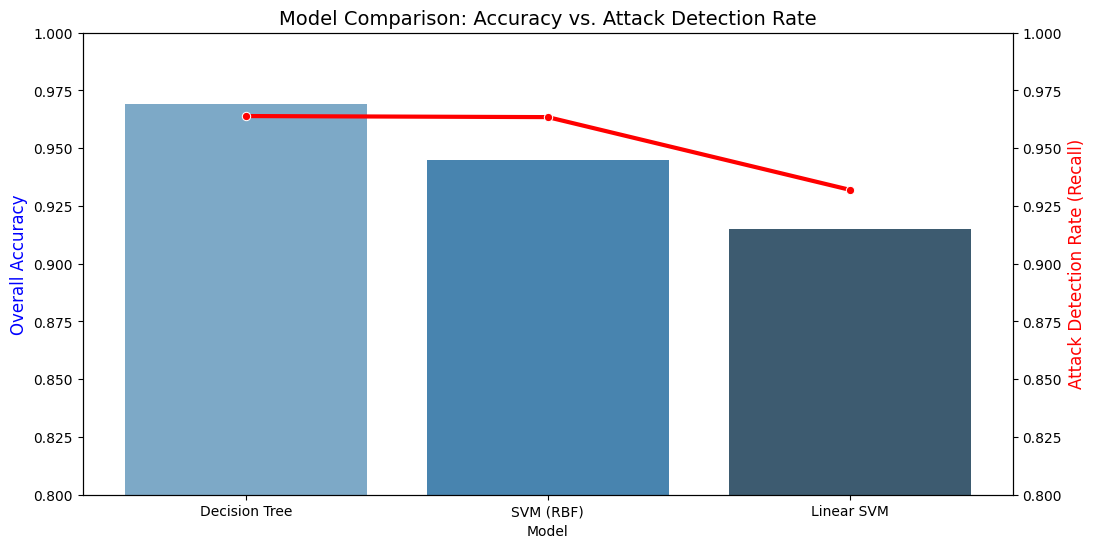

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, recall_score

# 1. Collect Accuracy and Detection Rate (Recall) for all models
model_list = []
if 'rf_bin' in locals(): model_list.append(('Random Forest', rf_bin))
if 'dt_bin' in locals(): model_list.append(('Decision Tree', dt_bin))
if 'svm_rbf' in locals(): model_list.append(('SVM (RBF)', svm_rbf))
if 'svm_fast' in locals(): model_list.append(('Linear SVM', svm_fast))

results_data = []
for name, model in model_list:
    preds = model.predict(X_test_b)
    acc = accuracy_score(y_test_b, preds)
    det_rate = recall_score(y_test_b, preds) # This is the "Attack Detection Rate"
    results_data.append({"Model": name, "Accuracy": acc, "Detection Rate": det_rate})

df_results = pd.DataFrame(results_data)

# 2. Print the Clear-Cut Summary
print("--- FINAL PERFORMANCE SUMMARY ---")
print(df_results.to_string(index=False))

# 3. Analyze "Where the Attack Happens"
if 'rf_bin' in locals():
    y_pred = rf_bin.predict(X_test_b)
    total_attacks = (y_test_b == 1).sum()
    detected = ((y_test_b == 1) & (y_pred == 1)).sum()
    print(f"\n--- ATTACK ANALYSIS ---")
    print(f"Out of {total_attacks} total attacks, the system caught {detected} of them.")
    print(f"Top Feature driving detection: '{selected_features[0]}' and 'rate'")

# 4. Visualization: Accuracy vs Detection Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Accuracy
sns.barplot(x="Model", y="Accuracy", data=df_results, palette="Blues_d", ax=ax1)
ax1.set_ylabel("Overall Accuracy", color="blue", fontsize=12)
ax1.set_ylim(0.8, 1.0)

# Line chart for Detection Rate (The "Graph Rate")
ax2 = ax1.twinx()
sns.lineplot(x="Model", y="Detection Rate", data=df_results, marker="o", color="red", linewidth=3, ax=ax2)
ax2.set_ylabel("Attack Detection Rate (Recall)", color="red", fontsize=12)
ax2.set_ylim(0.8, 1.0)

plt.title("Model Comparison: Accuracy vs. Attack Detection Rate", fontsize=14)
plt.show()

In [ ]:
import pandas as pd
from datetime import datetime

# 1. Define the Alert Function
def generate_alert(model_name, detection_count, accuracy):
    print(f"\n" + "="*45)
    print(f"🚨 ALERT GENERATED: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"SYSTEM STATUS: ATTACK DETECTED BY {model_name.upper()}")
    print(f"DETECTION CONFIDENCE (Accuracy): {accuracy:.2%}")
    print(f"NUMBER OF THREATS IDENTIFIED: {detection_count}")
    print(f"ACTION REQUIRED: Check 'sttl' and 'rate' values immediately.")
    print("="*45 + "\n")

# 2. Run Detection & Generate Alerts
# We use the test set (X_test_b) to simulate incoming traffic
models_to_check = []
if 'rf_bin' in locals(): models_to_check.append(("Random Forest", rf_bin))
if 'dt_bin' in locals(): models_to_check.append(("Decision Tree", dt_bin))

for name, model in models_to_check:
    predictions = model.predict(X_test_b)
    attack_indices = [i for i, val in enumerate(predictions) if val == 1]

    if len(attack_indices) > 0:
        # Calculate Accuracy for this specific model run
        acc = accuracy_score(y_test_b, predictions)
        # Generate the visual alert
        generate_alert(name, len(attack_indices), acc)

        # Show a snippet of the "Detected Attack" data
        print(f"--- Sample of Detected Attack Data ({name}) ---")
        display(X_test_b.iloc[attack_indices[:3]])


🚨 ALERT GENERATED: 2026-04-03 15:13:55
SYSTEM STATUS: ATTACK DETECTED BY DECISION TREE
DETECTION CONFIDENCE (Accuracy): 96.91%
NUMBER OF THREATS IDENTIFIED: 23230
ACTION REQUIRED: Check 'sttl' and 'rate' values immediately.

--- Sample of Detected Attack Data (Decision Tree) ---


,id,sttl,ct_state_ttl,dload,ct_dst_sport_ltm,dmean,rate,swin,dwin,ct_src_dport_ltm,ct_dst_src_ltm
54424,0.310391,0.996078,0.333333,0.000000,0.0,0.000000,0.125000,0.0,0.0,0.0,0.015625
58824,0.335485,0.996078,0.333333,0.000000,0.0,0.000000,1.000000,0.0,0.0,0.0,0.000000
85053,0.485075,0.243137,0.166667,0.000963,0.0,0.194787,0.000022,1.0,1.0,0.0,0.000000


In [ ]:
import pickle
from google.colab import files

# Save the winning Decision Tree and the Scaler
with open('final_model.pkl', 'wb') as f:
    pickle.dump(dt_bin, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Download to your computer for VS Code
files.download('final_model.pkl')
files.download('scaler.pkl')

NameError: name 'dt_bin' is not defined